## Process topo split results

In [1]:
# librariies
import xarray as xr
import numpy as np
import pandas as pd

from snobedo.snotel import SnotelLocations
from snobedo.snotel import SnotelLocations, CsvParser

from snobedo.lib.dask_utils import start_cluster, client_ip_and_port

from pathlib import Path, PurePath

import matplotlib.pyplot as plt

In [2]:
client = start_cluster(8, 24)
client_ip_and_port(client)

/uufs/chpc.utah.edu/common/home/u1037042/software/pkg/miniconda3/envs/snow_viz/lib/python3.12/site-packages/distributed/node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 42981 instead
  warnings.warn(
2025-05-05 14:57:17,419 - tornado.application - ERROR - Exception in callback functools.partial(<bound method IOLoop._discard_future_result of <tornado.platform.asyncio.AsyncIOMainLoop object at 0x7f096d234f20>>, <Task finished name='Task-16' coro=<SpecCluster._correct_state_internal() done, defined at /uufs/chpc.utah.edu/common/home/u1037042/software/pkg/miniconda3/envs/snow_viz/lib/python3.12/site-packages/distributed/deploy/spec.py:346> exception=RuntimeError('Command exited with non-zero exit code.\nExit code: 1\nCommand:\nsbatch /scratch/local/u1037042/4202883/tmpe6qdlgdo.sh\nstdout:\n\nstderr:\nsbatch: error: Batch job submission failed: Invalid qos specification\n\n')>)
Traceback (most recent call last

10.242.76.198:42981


In [3]:
# paths
S_STORE = PurePath("/uufs/chpc.utah.edu/common/home/uvu-group1/olson/snow-data/smeshr/net_HRRR_MODIS_SPIRES")
# net_dswrf.MST.20211110.nc
SHARED_STORE2 = PurePath("/uufs/chpc.utah.edu/common/home/u1037042/olson/snow-data/hrrr_toposplit")
# toposplit_20220218.nc

SHARED_STORE_RUN = PurePath("/uufs/chpc.utah.edu/common/home/u1037042/olson/snow-data/results/isnobal_simulations/hrrr_toposplit")
# erw_spires_dsw3_dlwrf/wy2022/erw_50m

SHARED_STORE = PurePath('/uufs/chpc.utah.edu/common/home/skiles-group1')
DATA_DIR = SHARED_STORE.joinpath('jmeyer')
SNOTEL_DIR = DATA_DIR.joinpath( 'Snotel')


year = 2022
water_year = f'wy{year}'

In [4]:
# focus on IRWIN
from pathlib import Path, PurePath
snotel_sites = SnotelLocations()
snotel_sites.load_from_json(SNOTEL_DIR / 'site-locations/snotel_sites.json')
snotel_sites.Irwin

SnotelSite(name='Irwin', lon=[317131], lat=[4306375])

In [5]:
schofield_snotel_csv = pd.concat([
    CsvParser.file(
        SNOTEL_DIR / water_year / f'Schofield/usda-csv/{year}-Schofield-Pass.csv',
    )
]).shift(22, freq='H')

butte_snotel_csv = pd.concat([
    CsvParser.file(
        SNOTEL_DIR /water_year  / f'Butte/usda-csv/{year}-Butte.csv',
    ),
]).shift(22, freq='H')

taylor_snotel_csv = pd.concat([
    CsvParser.file(
        SNOTEL_DIR / water_year / f'Taylor/usda-csv/{year}-Upper-Taylor.csv',
    )
]).shift(22, freq='H')


/scratch/local/u1037042/4202883/ipykernel_1211029/3703320429.py:5: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  ]).shift(22, freq='H')
/scratch/local/u1037042/4202883/ipykernel_1211029/3703320429.py:11: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  ]).shift(22, freq='H')
/scratch/local/u1037042/4202883/ipykernel_1211029/3703320429.py:17: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  ]).shift(22, freq='H')


In [6]:
irwin_csv = pd.concat([
    CsvParser.file(
        SNOTEL_DIR / water_year / f'Irwin/usda-csv/{year}-Irwin.csv',
    )
])

irwin_csv['Depth(m)'] = irwin_csv['Depth(m)'] / 10

## test single

In [7]:
test_dat = xr.open_mfdataset(
    f'{S_STORE}/net_dswrf.MST.20211110.nc'
)
test_dat.keys()

KeysView(<xarray.Dataset> Size: 158MB
Dimensions:              (time: 24, x: 656, y: 837)
Coordinates:
  * time                 (time) datetime64[ns] 192B 2021-11-10 ... 2021-11-10...
  * x                    (x) float64 5kB 3.159e+05 3.16e+05 ... 3.487e+05
  * y                    (y) float64 7kB 4.323e+06 4.323e+06 ... 4.281e+06
Data variables:
    transverse_mercator  |S1 1B ...
    albedo               (time, y, x) float32 53MB dask.array<chunksize=(1, 837, 656), meta=np.ndarray>
    dsw3                 (time, y, x) float32 53MB dask.array<chunksize=(1, 837, 656), meta=np.ndarray>
    net_solar            (time, y, x) float32 53MB dask.array<chunksize=(1, 837, 656), meta=np.ndarray>
Attributes:
    CDI:                 Climate Data Interface version 2.2.1 (https://mpimet...
    Conventions:         CF-1.5
    GDAL:                GDAL 3.5.3, released 2022/10/21
    history:             Tue Apr 22 12:12:14 2025: cdo -z zip4 -O -s splitday...
    GDAL_AREA_OR_POINT:  Area
    CDO:  

In [11]:
test_dat.net_solar

<xarray.DataArray 'net_solar' (time: 24, y: 837, x: 656)> Size: 53MB
dask.array<open_dataset-net_solar, shape=(24, 837, 656), dtype=float32, chunksize=(1, 837, 656), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 192B 2021-11-10 ... 2021-11-10T23:00:00
  * x        (x) float64 5kB 3.159e+05 3.16e+05 3.16e+05 ... 3.486e+05 3.487e+05
  * y        (y) float64 7kB 4.323e+06 4.323e+06 ... 4.281e+06 4.281e+06
Attributes:
    grid_mapping:  transverse_mercator

In [6]:
test_dat = xr.open_mfdataset(
    f'{SHARED_STORE_RUN}/erw_spires_dsw3_dlwrf/{water_year}/erw_50m/run20220215/snow.nc',
)
test_dat.keys()

KeysView(<xarray.Dataset> Size: 20MB
Dimensions:           (time: 1, y: 837, x: 656)
Coordinates:
  * time              (time) datetime64[ns] 8B 2022-02-15T22:00:00
  * y                 (y) float32 3kB 4.323e+06 4.323e+06 ... 4.281e+06
  * x                 (x) float32 3kB 3.159e+05 3.16e+05 ... 3.486e+05 3.487e+05
Data variables:
    thickness         (time, y, x) float32 2MB dask.array<chunksize=(1, 837, 656), meta=np.ndarray>
    snow_density      (time, y, x) float32 2MB dask.array<chunksize=(1, 837, 656), meta=np.ndarray>
    specific_mass     (time, y, x) float32 2MB dask.array<chunksize=(1, 837, 656), meta=np.ndarray>
    liquid_water      (time, y, x) float32 2MB dask.array<chunksize=(1, 837, 656), meta=np.ndarray>
    temp_surf         (time, y, x) float32 2MB dask.array<chunksize=(1, 837, 656), meta=np.ndarray>
    temp_lower        (time, y, x) float32 2MB dask.array<chunksize=(1, 837, 656), meta=np.ndarray>
    temp_snowcover    (time, y, x) float32 2MB dask.array<chunksiz

In [7]:
list(test_dat.keys())

['thickness',
 'snow_density',
 'specific_mass',
 'liquid_water',
 'temp_surf',
 'temp_lower',
 'temp_snowcover',
 'thickness_lower',
 'water_saturation',
 'projection']

In [8]:
import xarray as xr
from dask.distributed import Client

# Optional: start Dask client to monitor computation
client = Client()

# Path with wildcard to match folders like run20211003, run20211004, etc.
file_pattern = f"{SHARED_STORE_RUN}/erw_spires_dsw3_dlwrf/{water_year}/erw_50m/run*/snow.nc"

HRRR_solar_0 = xr.open_mfdataset(
    file_pattern,
    combine='by_coords',         
    parallel=True,               
    chunks={'time': 24},         
    preprocess=lambda ds: ds['thickness']
)

/uufs/chpc.utah.edu/common/home/u1037042/software/pkg/miniconda3/envs/snow_viz/lib/python3.12/site-packages/distributed/node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 46743 instead
  warnings.warn(


In [ ]:
# # erw_spires_dsw3_dlwrf/wy2022/erw_50m
# HRRR_solar_0 = xr.open_mfdataset(
#     f'{SHARED_STORE_RUN}/erw_spires_dsw3_dlwrf/{water_year}/erw_50m/run*/snow.nc',
#     parallel=True, chunks={'time': -1},
#     preprocess=lambda ds: ds['thickness']
# )

In [10]:
butte_snobal_hrrr = HRRR_solar_0.sel(x=snotel_sites.Butte.lon, y=snotel_sites.Butte.lat, method='nearest').compute()
schofield_snobal_hrrr = HRRR_solar_0.sel(x=snotel_sites.Schofield.lon, y=snotel_sites.Schofield.lat, method='nearest').compute()
taylor_snobal_hrrr = HRRR_solar_0.sel(x=snotel_sites.Taylor.lon, y=snotel_sites.Taylor.lat, method='nearest').compute()
irwin_snobal_hrrr = HRRR_solar_0.sel(x=snotel_sites.Irwin.lon, y=snotel_sites.Irwin.lat, method='nearest').compute()


In [27]:
del HRRR_solar_0

In [11]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
from matplotlib.offsetbox import AnchoredText

In [24]:
STATION_LABEL = 'Station'
COLORS = {
        'HRRR-MODIS': 'cornflowerblue',
        'DSW3-SPIRES': 'lightcoral',
        'Time-Decay': 'sandybrown',
        STATION_LABEL: 'seagreen',    
}

def plot_site(data, ax, site_name):
    for key in data:
        if key == STATION_LABEL:
            continue
        
        ax.plot(
            data[key].time,
            data[key].data.flatten(),
            label=key, 
            color=COLORS[key], 
            alpha=0.9, lw=1
        )
    ax.plot(
        data[STATION_LABEL].index,
        data[STATION_LABEL].values,
        label=key, 
        color=COLORS[STATION_LABEL], 
        alpha=0.9, lw=1.25
    ) 
    
    ax.set_ylabel(r'Snow Depth (m)')

    ax.tick_params(axis='x', which='minor', tick1On=False, tick2On=False)

    ax.set_xlim([plot_range[0], plot_range[-1]])
    ax.set_yticks(np.arange(0, 4))
    ax.set_ylim(bottom=-0.1)
    if year == 2021:
        ax.set_ylim(top=2.4)
    else:
        ax.set_ylim(top=3.3)
        
    ax.yaxis.set_minor_locator(mticker.MultipleLocator(0.2))
            
    at = AnchoredText(
        site_name, 
        prop=dict(size=10), 
        frameon=True, 
        loc='upper right', 
        pad=0.3, 
        borderpad=0.25,
    )
    at.patch.set_boxstyle("round", pad=0., rounding_size=0.2)
    at.patch.set(edgecolor='lightgrey')
    ax.add_artist(at)

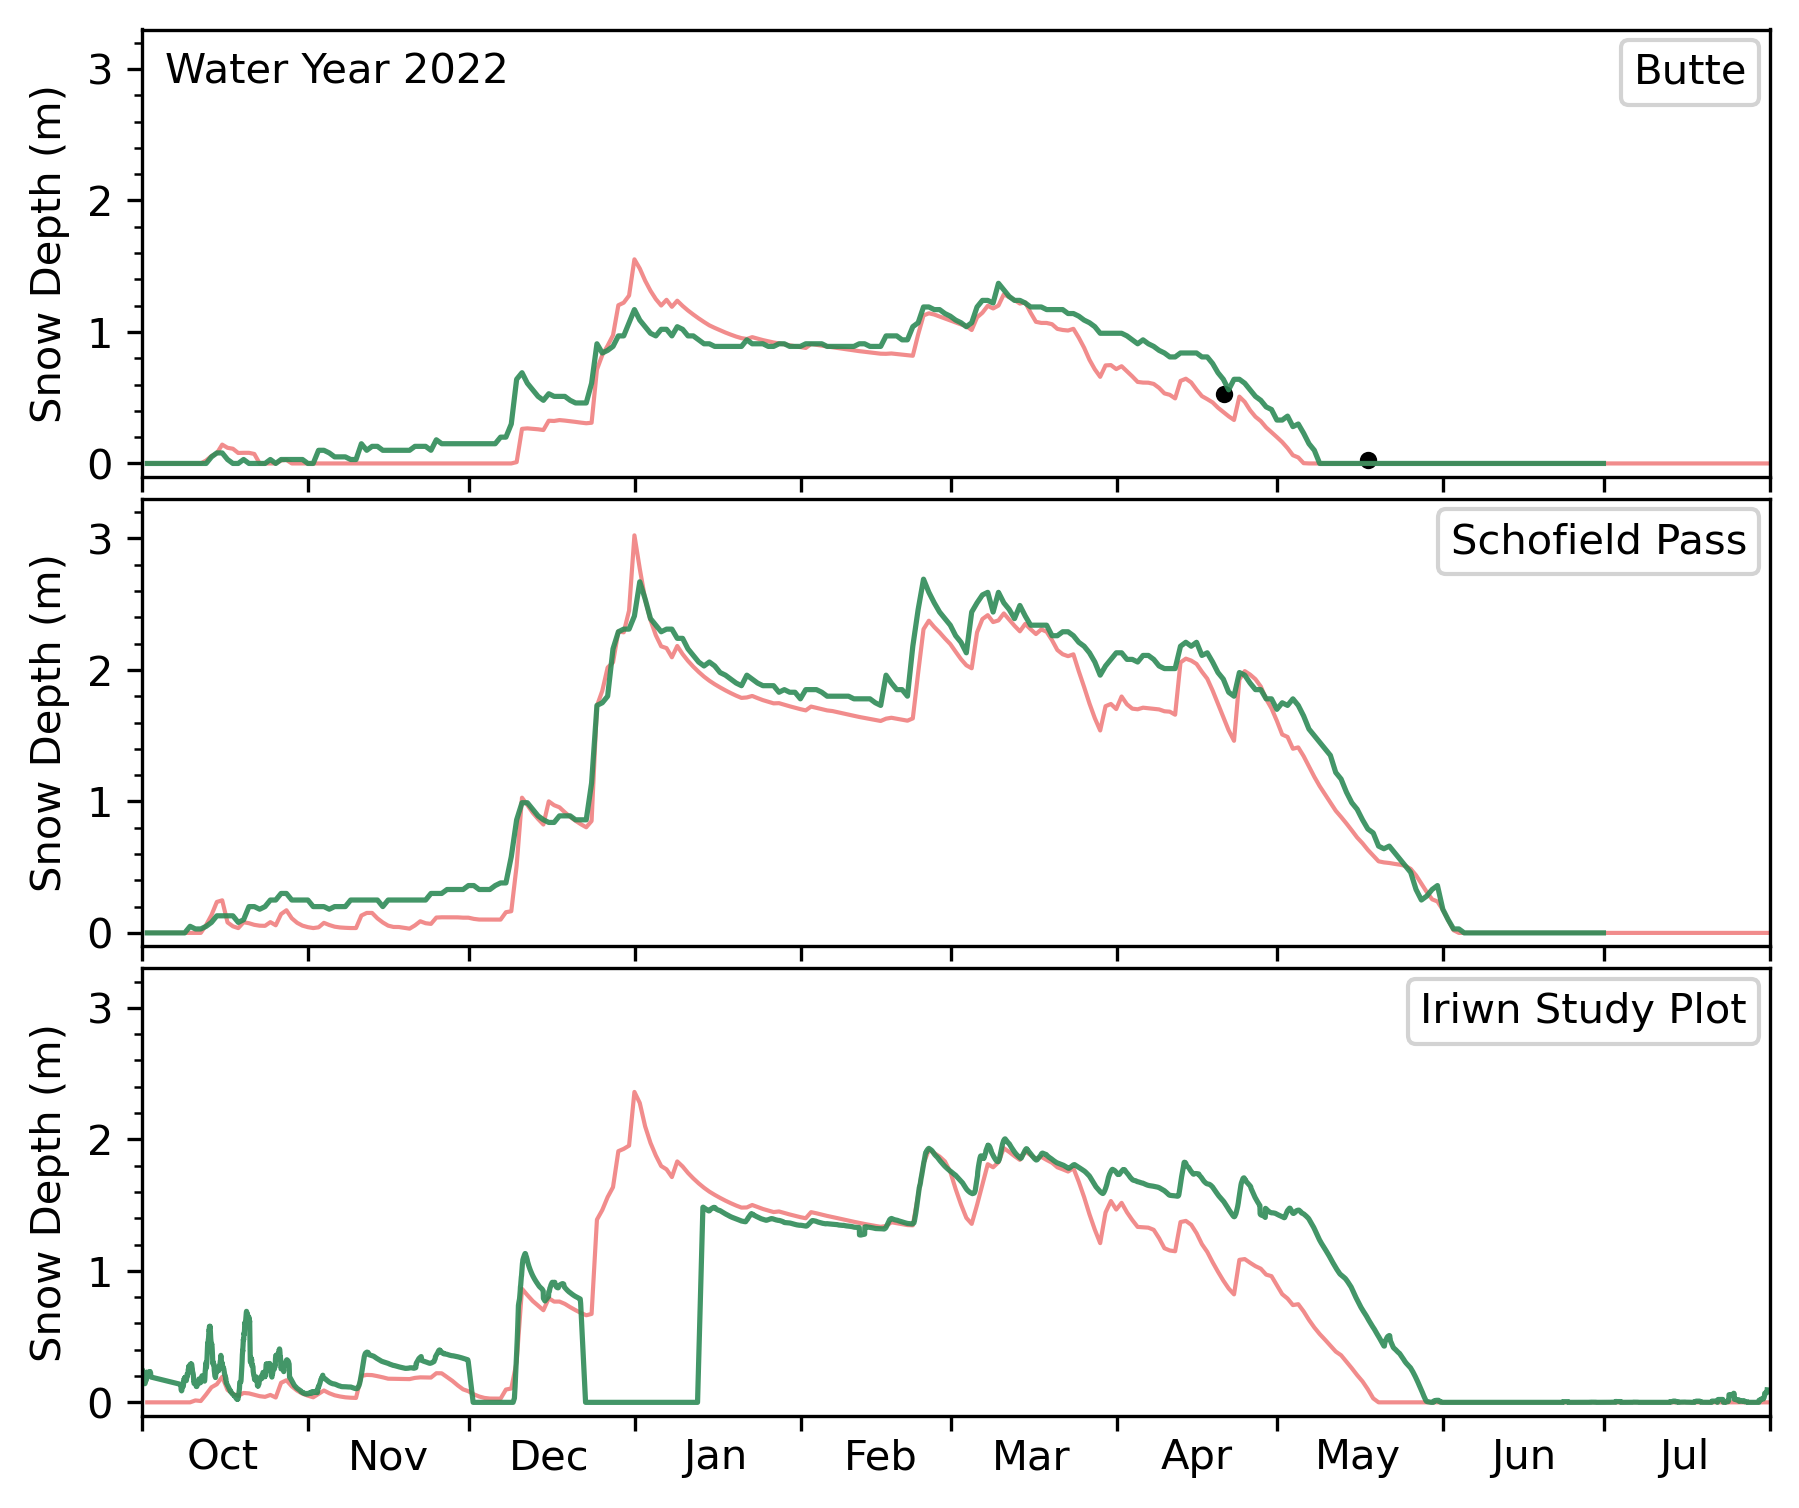

In [26]:
periods = 10 if year == 2021 else 11
plot_range = pd.date_range(start=f'{year - 1}-10-01', periods=periods, freq='MS')
xTicks = mdates.DateFormatter('%b')

figure_opts = dict(figsize=(7,6), dpi=300,)
fig, axes = plt.subplots(3, 1, sharex=True, **figure_opts)
plt.subplots_adjust(hspace=0.05)

plot_site(
    {
        # 'HRRR-MODIS': butte_snobal_hrrr_modis['thickness'],
        'DSW3-SPIRES': butte_snobal_hrrr['thickness'],
        # 'Time-Decay': butte_snobal['thickness'],
        STATION_LABEL: butte_snotel_csv['Depth(m)'],
    },
    axes[0],
    'Butte'
)

if year == 2022:
    aso_marker=dict(label='ASO', marker='o', c='black', s=10)
    axes[0].scatter(
        [np.datetime64('2022-04-21'), np.datetime64('2022-05-18')],
        [0.53, 0.03],
        **aso_marker
    )

plot_site(
    {
        # 'HRRR-MODIS': schofield_snobal_hrrr_modis['thickness'],
        'DSW3-SPIRES': schofield_snobal_hrrr['thickness'],
        # 'Time-Decay': schofield_snobal['thickness'],
        STATION_LABEL: schofield_snotel_csv['Depth(m)'],
    },
    axes[1],
    'Schofield Pass'
)

plot_site(
    {
        # 'HRRR-MODIS': irwin_snobal_hrrr_modis['thickness'],
        'DSW3-SPIRES': irwin_snobal_hrrr['thickness'],
        # 'Time-Decay': irwin_snobal['thickness'],
        STATION_LABEL: irwin_csv['Depth(m)'].rolling('1D').mean(),
    },
    axes[2],
    'Irwin Study Plot'
)
# if year == 2022:
#     axes[1].scatter( [], [], **aso_marker)

axes[1].xaxis.set_major_locator(mdates.MonthLocator())
axes[1].xaxis.set_minor_locator(mdates.MonthLocator(bymonthday=16))
axes[1].xaxis.set_major_formatter(mticker.NullFormatter())
axes[1].xaxis.set_minor_formatter(xTicks)
axes[1].tick_params(axis='x', which='minor', pad=-0.5)

at = AnchoredText(
    f'Water Year {year}', 
    prop=dict(size=10), 
    frameon=False, 
    loc='upper left', 
    pad=0.3, 
    borderpad=0.25,
)
axes[0].add_artist(at)
axes[1].legend(
    frameon=False,
    bbox_to_anchor=(0.95, -0.125),
    ncol=5,
    borderaxespad=0.15, 
    fontsize=8
);

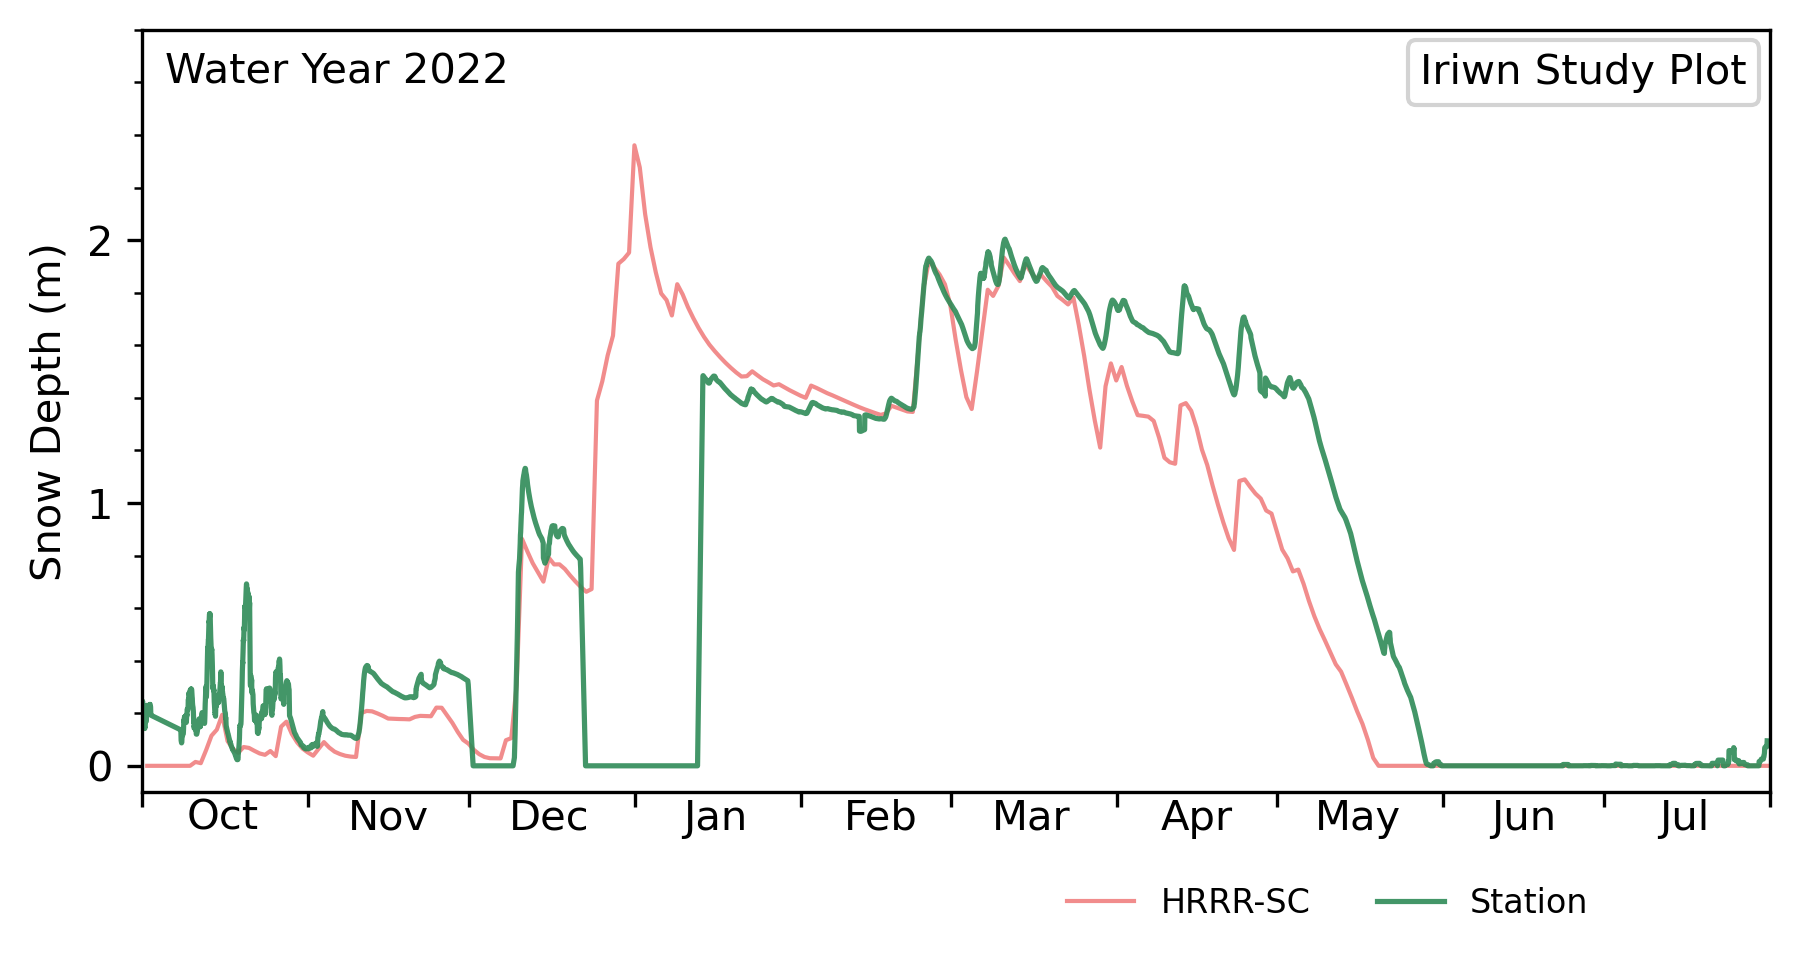

In [21]:
periods = 10 if year == 2021 else 11
plot_range = pd.date_range(start=f'{year - 1}-10-01', periods=periods, freq='MS')
xTicks = mdates.DateFormatter('%b')

figure_opts = dict(figsize=(7,3.3), dpi=300,)
fig, axes = plt.subplots(1, 1, sharex=True, **figure_opts)
plt.subplots_adjust(hspace=0.05)

plot_site(
    {
        # 'HRRR-MODIS': irwin_snobal_hrrr_modis['thickness'],
        'HRRR-SC': irwin_snobal_hrrr['thickness'],
        # 'Time-Decay': irwin_snobal['thickness'],
        STATION_LABEL: irwin_csv['Depth(m)'].rolling('1D').mean(),
    },
    axes,
    'Iriwn Study Plot'
)

axes.xaxis.set_major_locator(mdates.MonthLocator())
axes.xaxis.set_minor_locator(mdates.MonthLocator(bymonthday=16))
axes.xaxis.set_major_formatter(mticker.NullFormatter())
axes.xaxis.set_minor_formatter(xTicks)
axes.tick_params(axis='x', which='minor', pad=-0.5)
axes.set_ylim(top=2.8)

at = AnchoredText(
    f'Water Year {year}', 
    prop=dict(size=10), 
    frameon=False, 
    loc='upper left', 
    pad=0.3, 
    borderpad=0.25,
)
axes.add_artist(at)
axes.legend(
    frameon=False,
    bbox_to_anchor=(0.9, -0.1),
    ncol=5,
    borderaxespad=0.15, 
    fontsize=8
);

## test insolation

In [7]:
from dask.distributed import Client

# Optional: start Dask client to monitor computation
client = Client()

file_pattern = '/uufs/chpc.utah.edu/common/home/u1037042/olson/snow-data/hrrr_toposplit/toposplit_*.nc'

# file_pattern = f"{SHARED_STORE_RUN}/erw_spires_dsw3_dlwrf/{water_year}/erw_50m/run*/net_solar.nc"

HRRR_solar = xr.open_mfdataset(
    file_pattern,
    combine='by_coords',
    parallel=True, chunks={'time': 24}, # 'y' :10, 'x': 10},
)

# del HRRR_solar

In [20]:
HRRR_solar

<xarray.Dataset> Size: 80GB
Dimensions:     (time: 7320, y: 837, x: 656)
Coordinates:
  * x           (x) float32 3kB 3.159e+05 3.16e+05 ... 3.486e+05 3.487e+05
  * y           (y) float32 3kB 4.323e+06 4.323e+06 ... 4.281e+06 4.281e+06
  * time        (time) datetime64[ns] 59kB 2021-09-30T06:00:00 ... 2022-08-01...
Data variables:
    ghi         (time, y, x) float32 16GB dask.array<chunksize=(24, 837, 656), meta=np.ndarray>
    dsw1        (time, y, x) float32 16GB dask.array<chunksize=(24, 837, 656), meta=np.ndarray>
    dsw2        (time, y, x) float32 16GB dask.array<chunksize=(24, 837, 656), meta=np.ndarray>
    dsw3        (time, y, x) float32 16GB dask.array<chunksize=(24, 837, 656), meta=np.ndarray>
    k           (time, y, x) float32 16GB dask.array<chunksize=(24, 837, 656), meta=np.ndarray>
    projection  (time) |S1 7kB b'' b'' b'' b'' b'' b'' ... b'' b'' b'' b'' b''
Attributes:
    description:  HRRR topographic split model
    history:      Created 2025-04-21 17:01:58.551783
    source:       HRRR model + custom topo-splitting

In [8]:
irwin_dsw1 = HRRR_solar.dsw1.sel(x=snotel_sites.Irwin.lon, y=snotel_sites.Irwin.lat, method='nearest').squeeze(['x', 'y']).compute()
irwin_dsw3 = HRRR_solar.dsw3.sel(x=snotel_sites.Irwin.lon, y=snotel_sites.Irwin.lat, method='nearest').squeeze(['x', 'y']).compute()
irwin_k = HRRR_solar.k.sel(x=snotel_sites.Irwin.lon, y=snotel_sites.Irwin.lat, method='nearest').squeeze(['x', 'y']).compute()


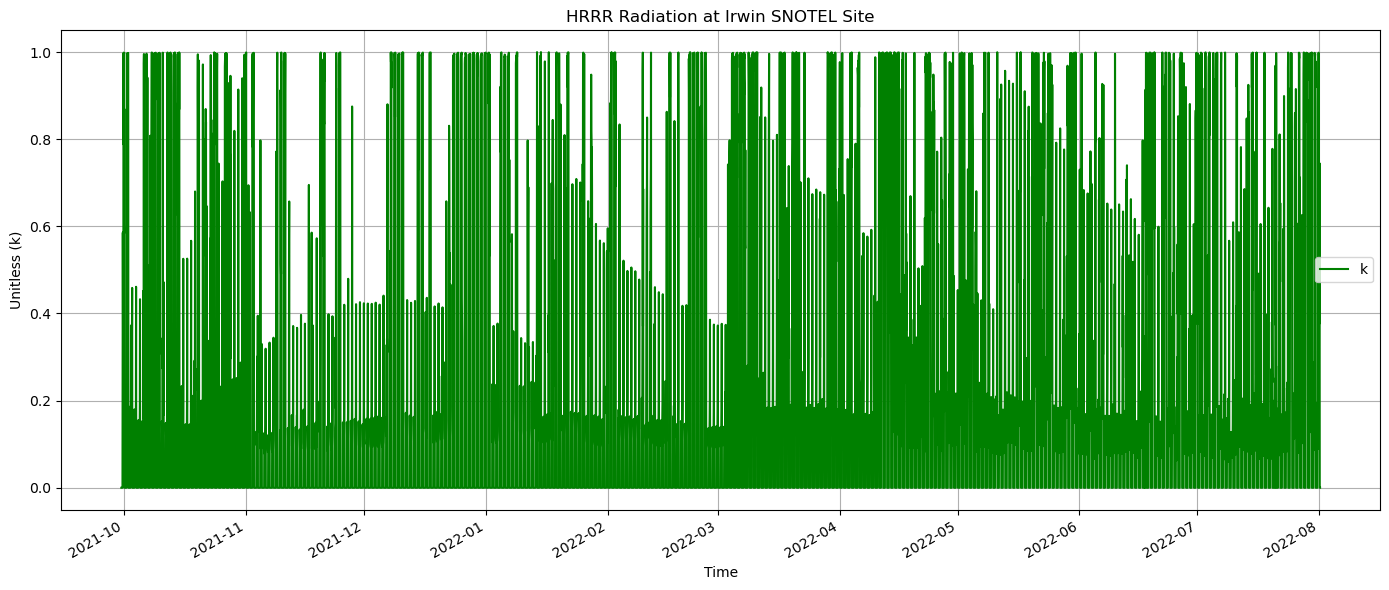

In [9]:
import matplotlib.pyplot as plt

# Create the figure and axis
fig, ax = plt.subplots(figsize=(14, 6))

# Plot each variable
# ax.plot(irwin_dsw1.time, irwin_dsw1, label='DSW1', color='orange')
# ax.plot(irwin_dsw3.time, irwin_dsw3, label='DSW3', color='blue')
ax.plot(irwin_k.time, irwin_k, label='k', color='green')

# Formatting
ax.set_title('HRRR Radiation at Irwin SNOTEL Site')
ax.set_xlabel('Time')
ax.set_ylabel('Radiation (W/m²) or unitless (k)')
ax.set_ylabel('Unitless (k)')
ax.legend()
ax.grid(True)
fig.autofmt_xdate()

plt.tight_layout()
plt.show()


In [26]:


# Use Dask-aware xarray reductions
k = irwin_k

k_stats = {
    'min': k.min().compute().item(),
    'max': k.max().compute().item(),
    'mean': k.mean().compute().item(),
    'median': k.median().compute().item(),
    'std': k.std().compute().item(),
    '25th percentile': k.quantile(0.25).compute().item(),
    '75th percentile': k.quantile(0.75).compute().item(),
    'count (non-NaN)': k.count().compute().item(),
    'NaN count': k.size - k.count().compute().item()
}

# Print nicely
print("Global Statistics for k:")
for key, val in k_stats.items():
    print(f"{key:>18}: {val:.4f}")



Global Statistics for k:
               min: 0.0000
               max: 0.9999
              mean: 0.2087
            median: 0.0000
               std: 0.3326
   25th percentile: 0.0000
   75th percentile: 0.2143
   count (non-NaN): 7320.0000
         NaN count: 0.0000


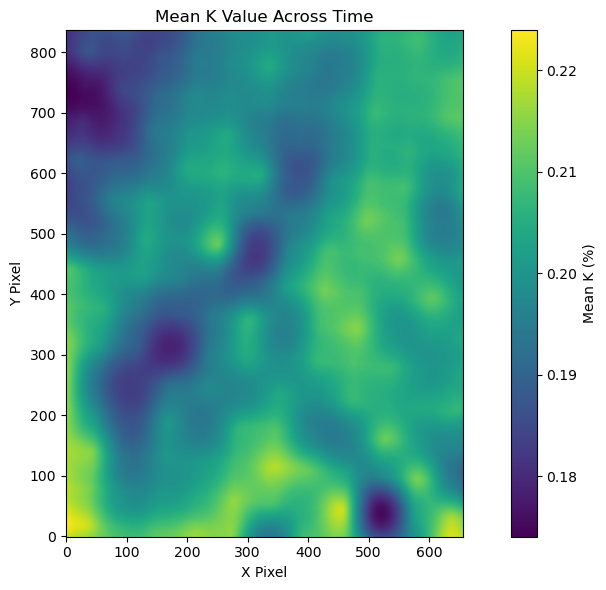

In [22]:
import dask.array as da
import numpy as np
import matplotlib.pyplot as plt

# Assume HRRR_solar is your xarray dataset
# Get the 'k' variable (using Dask array)
k_data = HRRR_solar['k']

# Calculate the mean of 'k' across the time axis (axis 0)
# This will result in a (y, x) array of the mean values
mean_k = k_data.mean(axis=0).compute()  # .compute() triggers the actual computation

# Plot the mean 'k' value (time-averaged) as an image
plt.figure(figsize=(10, 6))
plt.imshow(mean_k, cmap='viridis', origin='lower')
plt.colorbar(label='Mean K (%)')
plt.title('Mean K Value Across Time')
plt.xlabel('X Pixel')
plt.ylabel('Y Pixel')
plt.tight_layout()
plt.show()


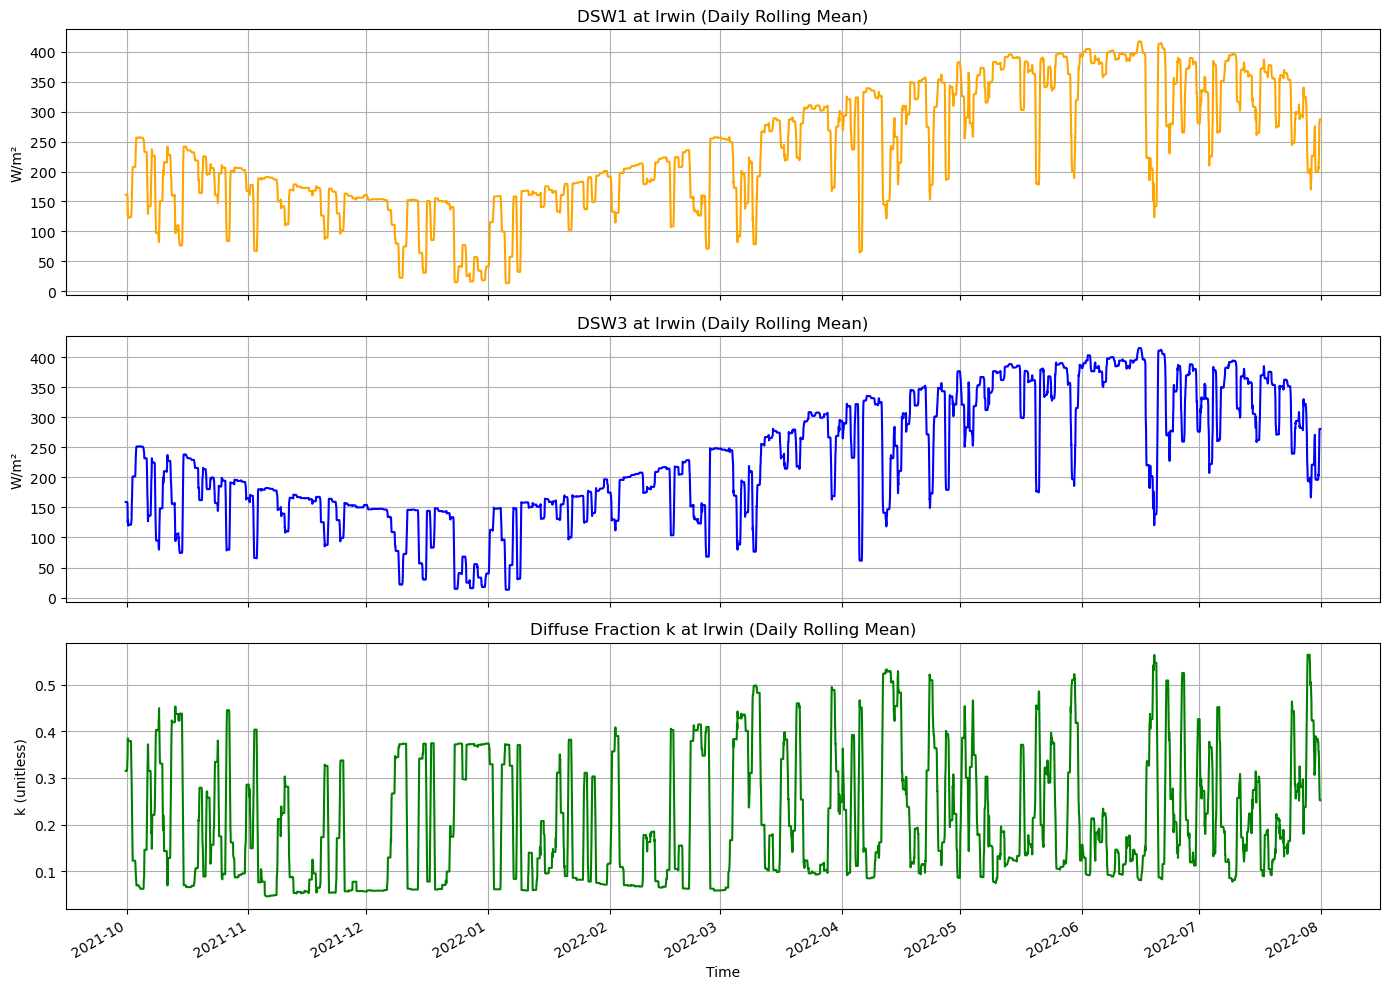

In [14]:
import matplotlib.pyplot as plt

# Apply daily rolling mean (24-hour window)
irwin_dsw1_ = irwin_dsw1.where(irwin_dsw1 > 0 )
irwin_dsw3_ = irwin_dsw3.where(irwin_dsw3 > 0 )
irwin_k_ = irwin_k.where(irwin_k > 0 )

win = 24
dsw1_daily = irwin_dsw1.rolling(time=win, center=True).mean()
dsw3_daily = irwin_dsw3.rolling(time=win, center=True).mean()
k_daily = irwin_k.rolling(time=win, center=True).mean()

# Set up the stacked plots
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(14, 10), sharex=True)

# Plot DSW1
axes[0].plot(dsw1_daily.time, dsw1_daily, color='orange')
axes[0].set_title('DSW1 at Irwin (Daily Rolling Mean)')
axes[0].set_ylabel('W/m²')
axes[0].grid(True)

# Plot DSW3
axes[1].plot(dsw3_daily.time, dsw3_daily, color='blue')
axes[1].set_title('DSW3 at Irwin (Daily Rolling Mean)')
axes[1].set_ylabel('W/m²')
axes[1].grid(True)

# Plot k
axes[2].plot(k_daily.time, k_daily, color='green')
axes[2].set_title('Diffuse Fraction k at Irwin (Daily Rolling Mean)')
axes[2].set_ylabel('k (unitless)')
axes[2].set_xlabel('Time')
axes[2].grid(True)

# Auto format date ticks
fig.autofmt_xdate()
plt.tight_layout()
plt.show()


In [ ]:
## COMPARE WITH STATION

In [12]:
PD_OPTS = dict(
    parse_dates=True,
    index_col=0,
    names=['Temp', 'VIS_IN', 'NIR_IN', 'VIS_OUT', 'NIR_OUT'],
    header=0,
)

irwin_pyra = pd.concat([
    pd.read_csv(DATA_DIR / 'Snotel/wy2021/Irwin/2021-Irwin.csv', **PD_OPTS),
    pd.read_csv(DATA_DIR / 'Snotel/wy2022/Irwin/2022-Irwin.csv', **PD_OPTS),
])

irwin_pyra = irwin_pyra.fillna({'VIS_IN': 0}).astype(np.float64)

In [15]:
PD_OPTS = dict(
    parse_dates=True,
    index_col=0,
    names=['Temp', 'VIS_IN', 'NIR_IN', 'VIS_OUT', 'NIR_OUT'],
    header=0,
)
irwin_pyra = pd.concat([
    pd.read_csv(DATA_DIR / 'Snotel/wy2021/Irwin/2021-Irwin.csv', **PD_OPTS),
    pd.read_csv(DATA_DIR / 'Snotel/wy2022/Irwin/2022-Irwin.csv', **PD_OPTS),
])
irwin_pyra = irwin_pyra.fillna({'VIS_IN': 0}).astype(np.float64)

# add net solar
# removed
# ROLL_WINDOW = 32
# .rolling(ROLL_WINDOW).mean().interpolate('time')
irwin_pyra['net_solar'] = (
    irwin_pyra['VIS_IN'] + irwin_pyra['NIR_IN'] - irwin_pyra['VIS_OUT'] - irwin_pyra['NIR_OUT']
)
irwin_pyra['albedo'] = (
    (0.67 * (irwin_pyra['VIS_OUT'] / irwin_pyra['VIS_IN'])) + (0.33 * (irwin_pyra['NIR_OUT'] / irwin_pyra['NIR_IN']))
)

irwin_pyra

,Temp,VIS_IN,NIR_IN,VIS_OUT,NIR_OUT,net_solar,albedo
2020-10-01 00:00:00,17.720,163.543700,103.276300,11.493210,9.229739,246.097051,0.076577
2020-10-01 00:15:00,16.440,63.947490,33.248880,4.676552,3.648914,88.870904,0.085214
2020-10-01 00:30:00,14.660,15.168280,0.537851,2.475997,1.642848,11.587285,1.117343
2020-10-01 00:45:00,13.020,9.152243,-0.413845,1.890282,1.210260,5.637856,-0.826682
2020-10-01 01:00:00,11.750,3.064336,-1.182064,1.390139,1.077668,-0.585535,0.003091
...,...,...,...,...,...,...,...
2022-06-25 13:30:00,1.267,67.807140,19.912140,9.272700,6.692386,71.754194,0.202535
2022-06-25 13:45:00,1.821,274.049800,124.711700,26.574190,21.086890,351.100420,0.120767
2022-06-25 14:00:00,4.256,340.697400,167.584100,45.274410,36.379280,426.627810,0.160671
2022-06-25 14:15:00,7.532,382.882000,191.219500,58.465750,46.475040,469.160710,0.182513


In [ ]:
mean_ghi = ds['ghi'].mean(dim='time').compute()
mean_dsw1 = ds['dsw1'].mean(dim='time').compute()
mean_dsw2 = ds['dsw2'].mean(dim='time').compute()
mean_dsw3 = ds['dsw3'].mean(dim='time').compute()
mean_k = ds['k'].mean(dim='time').compute()


In [20]:
mean_ds = ds[['ghi', 'dsw1', 'dsw2', 'dsw3', 'k']].mean(dim='time').compute()


NameError: name 'ds' is not defined

## Multiple at a time

In [ ]:
# 3. HRRR + MODIS
net_solar = xr.open_mfdataset(
    f'{S_STORE}/net_dswrf.MST.*.nc',
    parallel=True, chunks={'time': 24}, # 'y' :10, 'x': 10},
    drop_variables=['DSWRF', 'DSW'],
)

irwin_snobal_hrrr_modis = HRRR_solar.net_solar.sel(x=snotel_sites.Irwin.lon, y=snotel_sites.Irwin.lat, method='nearest').squeeze(['x', 'y']).compute()
irwin_snobal_hrrr_modis_albedo = HRRR_solar.albedo.sel(x=snotel_sites.Irwin.lon, y=snotel_sites.Irwin.lat, method='nearest').squeeze(['x', 'y']).compute()/10000

del HRRR_solar

In [ ]:
solar_SMRF = xr.open_mfdataset(
    f'{S_STORE}/net_dswrf.MST.*.nc',
    parallel=True, chunks={'time': -1},
    preprocess=lambda ds: ds['thickness'],
)

butte_snobal = solar_SMRF.sel(x=snotel_sites.Butte.lon, y=snotel_sites.Butte.lat, method='nearest').compute()
schofield_snobal = solar_SMRF.sel(x=snotel_sites.Schofield.lon, y=snotel_sites.Schofield.lat, method='nearest').compute()
taylor_snobal = solar_SMRF.sel(x=snotel_sites.Taylor.lon, y=snotel_sites.Taylor.lat, method='nearest').compute()
irwin_snobal = solar_SMRF.sel(x=snotel_sites.Irwin.lon, y=snotel_sites.Irwin.lat, method='nearest').compute()

del solar_SMRF